In [1]:
import tools

In [2]:
import time

In [3]:
tools.ext.np.set_printoptions(precision=8, suppress=True, floatmode="fixed")

In [4]:
vol1 = tools.ext.nib.load("../../../sub-1/ses-4/anat/sub-1_ses-4_acq-wipcs_T1w.nii.gz")

In [5]:
A1 = vol1.get_fdata()
aff1 = vol1.affine
print(A1.shape)

(160, 512, 512)


In [6]:
tools.ext.reload(tools)

<module 'tools' from '/home/becqg/data/2024Phantom3D/derivatives/1-validate-orientations/code/tools.py'>

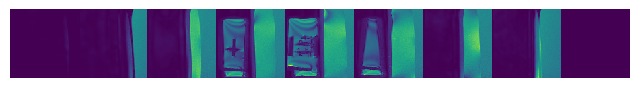

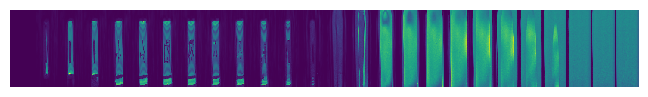

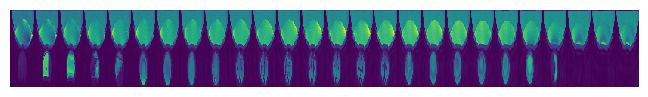

In [7]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1, mode, 20, decimate=5); 

In [8]:
A1r = A1[40:-40, :-260, 140:-140]

In [9]:
tools.ext.np.around(aff1, 2)

array([[  1.00000000,  -0.01000000,   0.01000000, -77.53000000],
       [ -0.05000000,  -0.00000000,   0.23000000, -39.50000000],
       [ -0.04000000,  -0.23000000,  -0.00000000, 138.12000000],
       [  0.00000000,   0.00000000,   0.00000000,   1.00000000]])

In [10]:
tools.ext.np.sum(aff1 ** 2, 0) ** 0.5

array([  0.99999998,   0.23437500,   0.23437500, 163.24495759])

In [11]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1r, (1, 0.234375, 0.234375), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2 - t1)

89.75522303581238


In [12]:
A2.shape

(65, 48, 44)

In [14]:
(A0, aff0) = tools.load_template("../templates/template-phantom-mri_resolution-1250.nii.gz")

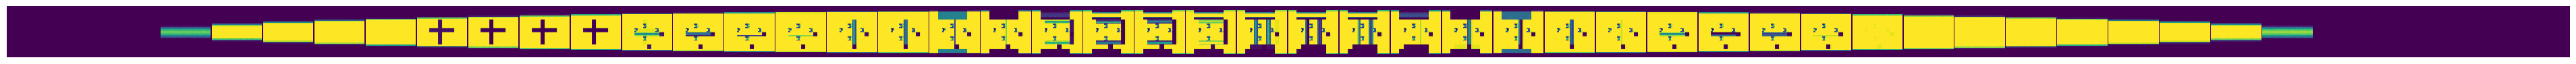

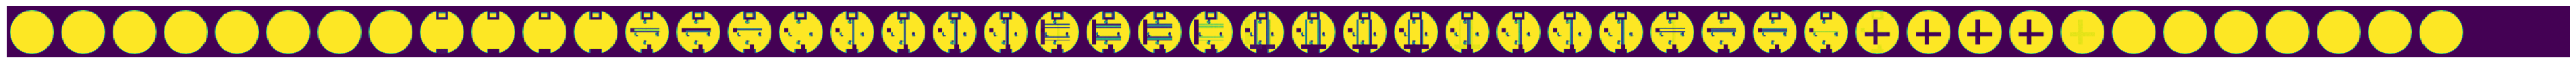

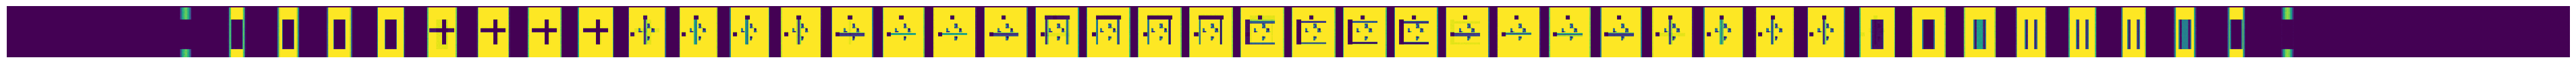

In [15]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [16]:
A0.shape

(49, 49, 49)

In [17]:
A0r = A0[9:-9, 9:-9, 9:-9]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(31, 31, 31)


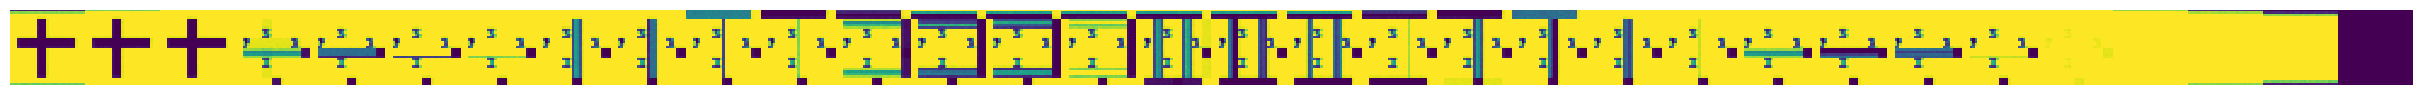

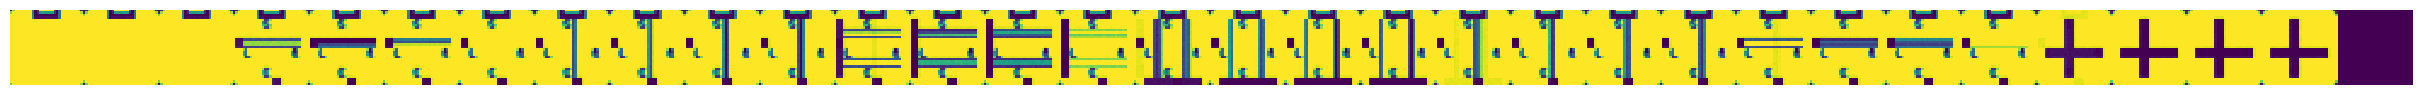

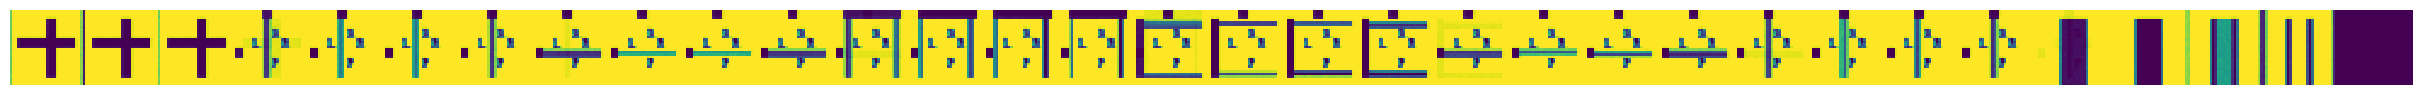

In [18]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode); 

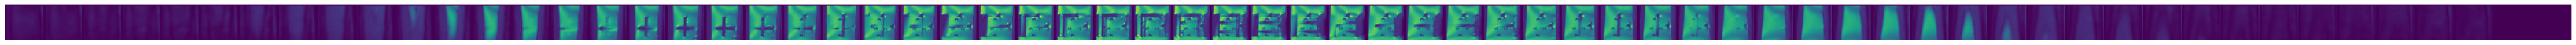

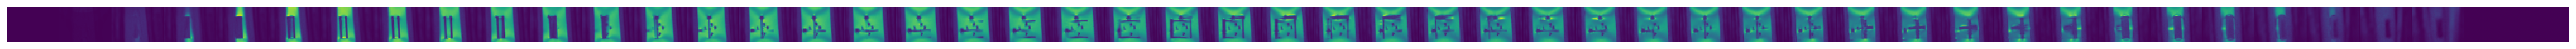

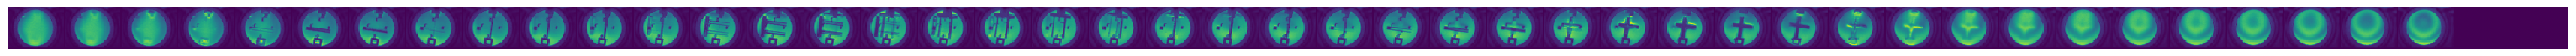

In [19]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode); 

In [20]:
res = {}
t1 = time.time()
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

87.73390531539917


In [21]:
df3

,i,j,k,c
"False_False_False_(1, 0, 2)",14.0,10.0,12.0,0.872577
"True_False_False_(1, 0, 2)",15.0,9.0,4.0,0.873330
"True_True_False_(0, 1, 2)",14.0,7.0,3.0,0.875826
"True_False_False_(0, 1, 2)",16.0,10.0,12.0,0.876068
"True_True_True_(0, 1, 2)",17.0,9.0,12.0,0.876397
"True_False_True_(0, 1, 2)",17.0,8.0,12.0,0.879198
"False_True_False_(1, 0, 2)",15.0,8.0,2.0,0.880445
"False_True_True_(2, 1, 0)",14.0,8.0,12.0,0.880755
"False_True_True_(0, 1, 2)",17.0,8.0,7.0,0.880882
"False_False_True_(2, 0, 1)",14.0,9.0,1.0,0.881017


In [22]:
print(tools.ext.np.around(aff1, 3))

[[  0.99800000  -0.00900000   0.01200000 -77.53000000]
 [ -0.05300000  -0.00100000   0.23400000 -39.50300000]
 [ -0.03900000  -0.23400000  -0.00100000 138.11800000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [23]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)
print(flips1, orientations1)

[False, False, True] [np.int64(0), np.int64(2), np.int64(1)]


In [ ]:
(flips2, orientations2) = ([False, False, True], [0, 2, 1])

In [ ]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)